In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

# OpenAI API를 활용한 이미지 생성 및 편집 튜토리얼
이 Jupyter Notebook에서는 OpenAI의 gpt-image-1-mini 모델 API를 활용하여 텍스트로부터 이미지 생성 및 기존 이미지 편집(Inpainting/Outpainting) 기능을 구현하는 방법을 소개합니다.

### 주요 학습 내용:
1. gpt-image-1-mini 모델 개요 및 환경 설정
2. OpenAI API 클라이언트 생성
3. 기본 이미지 생성
4. 이미지 편집

## 1. gpt-image-1-mini 모델 개요
gpt-image-* 는 OpenAI가 개발한 최첨단 이미지 생성 AI 모델로, 텍스트로 설명한 내용을 바탕으로 새로운 이미지를 만들어냅니다. 예를 들어 *"우주비행사가 말을 타고 있는 사진"*이라는 프롬프트를 주면, 우주비행사가 말 위에 올라탄 독창적이고 현실감 있는 이미지를 생성할 수 있습니다. 자연어 설명만으로 사실적인 이미지와 예술 작품을 생성할 수 있으며, 여러 개념과 속성, 스타일을 조합하여 창의적인 결과물을 만들어냅니다.
2023년에 공개된 DALL-E 2와 3 모델은 2026년 6월에 폐기함.

## 2. OpenAI API 클라이언트 생성


In [2]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
client = OpenAI()

위 코드에서는 .env에서 불러온 API 키로 client 객체를 생성했습니다. 이제 이 client를 통해 gpt-image-1-mini를 비롯한 OpenAI API 요청을 보낼 수 있습니다. (참고로, api_key를 생략하면 OPENAI_API_KEY 환경 변수를 자동으로 참조합니다.)

## 3. 기본 이미지 생성
텍스트 프롬프트를 사용한 이미지 생성은 gpt-image-1-mini의 가장 기본적인 기능입니다. 앞서 생성한 OpenAI client를 사용하여 원하는 내용을 설명하는 프롬프트를 전달하면, 해당 설명에 부합하는 이미지를 얻을 수 있습니다.

### 이미지 생성 요청하기
OpenAI Python SDK에서는 이미지 생성을 위해 client.images.generate() 메서드를 제공합니다. 가장 간단한 형태로 이 메서드에 프롬프트 문자열만 전달하면 한 장의 이미지를 생성합니다. 예를 들어 다음 코드는 "숲이 보이는 밝은 자연 이미지를 그려줘"이라는 간단한 프롬프트로 이미지를 생성하는 요청을 만듭니다:

In [3]:
prompt_text = '숲이 보이는 밝은 자연 이미지를 그려줘'
response = client.images.generate(
            model='gpt-image-1-mini', # 모델명
            prompt=prompt_text,       # 생성될 이미지 설명
            n=1,                      # 생성될 이미지 갯수
            size="1024x1024"          # 이미지 해상도    
)

In [5]:
import base64
b64_data = response.data[0].b64_json

# base64 문자열을 실제 이미지 파일(png)로 디코딩해서 저장
image_bytes = base64.b64decode(b64_data)

with open('data/ch4_forest.png', 'wb') as f:
    f.write(image_bytes)
print('이미지 저장 완료')

이미지 저장 완료


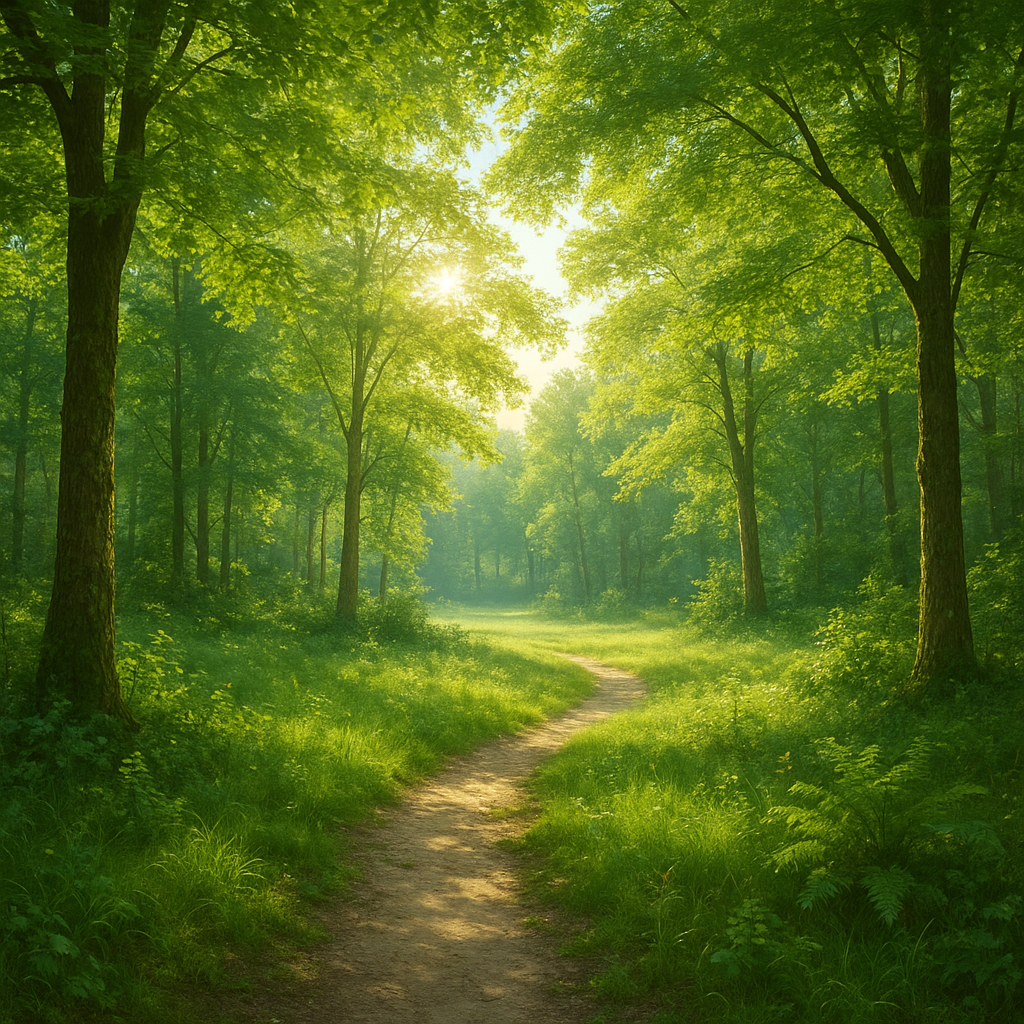

In [7]:
from IPython.display import display, Image
display(Image(image_bytes, width=200))

위 코드는 동일한 prompt에 quality="low" 옵션을 추가하여 이미지를 생성한 예시입니다. gptimage-1-mini는 quality를 "low", "medium", "high", "auto"(기본값) 중에서 선택할 수 있으며, quality 를 낮출수록 토큰 사용량과 비용이 줄어듭니다. 참고로 gpt-image-1-mini는 256x256, 512x512처럼 더 작은 정사각형 해상도는 지원하지 않으며, "1024x1024", "1536x1024", "1024x1536", "auto"중에서만 크기를 선택할 수 있습니다(과거 DALL-E 2가 지원하던 256x256, 512x512 같은 작은 해상도는, DALL-E 2가 2026년 5월 API에서 제거되면서 함께 사라졌습니다).

참고: gpt-image-1-mini를 비롯한 GPT 이미지 계열 모델(gpt-image-1, gpt-image-1.5 등)은 URL이 아니라 항상 b64_json(base64로 인코딩된 이미지 데이터) 형태로만 결과를 반환합니다. 따라서 response.data[0].b64_json 값을 base64.b64decode()로 디코딩한 뒤 파일로 저장하거나 화면에 표시해야 합니다. (URL 방식은 과거 DALL-E 2, DALL-E 3에서 기본으로 제공되던 방식이었으나, 두 모델 모두 현재는 API에서 제거되어 더 이상 사용할 수 없습니다.)

In [ ]:
prompt_text = '숲이 보이는 밝은 자연 이미지를 그려줘'
response = client.images.generate(
            model='gpt-image-1-mini', # 모델명
            prompt=prompt_text,       # 생성될 이미지 설명
            n=1,                      # 생성될 이미지 갯수
            size="1024x1024",         # 이미지 해상도    
            quality='low'             # low/medium/high/auto 중 선택. 낮을수록 토큰 비용 절감. 기본값은 auto
)

In [ ]:
import base64
b64_data = response.data[0].b64_json

# base64 문자열을 실제 이미지 파일(png)로 디코딩해서 저장
image_bytes = base64.b64decode(b64_data)

with open('data/ch4_forest_low.png', 'wb') as f:
    f.write(image_bytes)
print('이미지 저장 완료')

### quality 옵션으로 고품질 이미지 생성하기
앞서 언급했듯, OpenAI는 한때 DALL-E 2(기본값)와 DALL-E 3 두 가지 모델을 이미지 생성 API로
제공했지만, 두 모델 모두 2026년 5월 API에서 제거되었습니다. 현재는 gpt-image-1-mini, gptimage-1, gpt-image-1.5 등 GPT 이미지 계열 모델만 사용할 수 있으며, 이 중 토큰당 비용이 가
장 저렴한 모델이 gpt-image-1-mini입니다. DALL-E 3가 제공하던 "고품질" 옵션은 gpt-image-1-
mini의 quality 파라미터로 대체할 수 있습니다. 예를 들어 더 높은 품질의 이미지를 얻으려면 위
요청을 다음과 같이 변경합니다::

In [ ]:
prompt_text = '숲이 보이는 밝은 자연 이미지를 그려줘'
response = client.images.generate(
            model='gpt-image-1-mini', # 모델명
            prompt=prompt_text,       # 생성될 이미지 설명
            n=1,                      # 생성될 이미지 갯수
            size="1024x1024",         # 이미지 해상도("1024x1024", "1536x1024", "1024x1536", "auto")    
            quality='high'             # low/medium/high/auto 중 선택. 낮을수록 토큰 비용 절감. 기본값은 auto
)

In [ ]:
import base64
b64_data = response.data[0].b64_json

# base64 문자열을 실제 이미지 파일(png)로 디코딩해서 저장
image_bytes = base64.b64decode(b64_data)

with open('data/ch4_forest_high.png', 'wb') as f:
    f.write(image_bytes)
print('이미지 저장 완료')

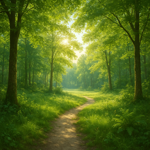

In [10]:
from PIL import Image
from io import BytesIO
# image = Image.open('data/ch4_forest.png')
image = Image.open(BytesIO(image_bytes))
image.resize((150,150))

- quality: gpt-image-1-mini의 옵션으로, "low", "medium", "high", "auto"(기본값) 중 하나를 지정합
니다. "high"는 더 높은 이미지 품질을 제공하지만 생성 비용(토큰 사용량)과 시간이 증가합니다.
"low"는 빠르고 비용이 저렴하지만 품질이 다소 낮습니다.
- style: DALL-E 3에만 있던 옵션으로, gpt-image-1-mini를 비롯한 GPT 이미지 계열 모델에는 이 파
라미터가 없습니다. 색감이나 분위기를 조정하고 싶다면 prompt 문구에 직접 원하는 스타일(예: "
선명하고 화려한 색감으로", "차분하고 자연스러운 톤으로")을 설명해주는 방식으로 대체해야 합니
다.
주의: gpt-image-1-mini는 한 번의 API 호출로 n=1~10장까지 이미지를 생성할 수 있어, 여러 시
안을 한 번에 비교할 때 유용합니다. 다만 지원하는 해상도는 "1024x1024"(정사각형),
"1536x1024"(가로형), "1024x1536"(세로형), "auto"뿐이며, 과거 DALL-E 2가 지원하던 256x256,
512x512 같은 작은 해상도는 더 이상 생성할 수 없습니다. 작은 이미지가 필요하다면 1024x1024
로 생성한 뒤 Pillow(PIL) 등으로 리사이즈해서 사용해야 합니다

## 4. 이미지 편집
이제 기존 이미지를 편집하는 방법을 알아보겠습니다. OpenAI Images API(gpt-image-1-mini 등)는
이미지 편집(edit) 기능을 통해 **인페인팅(Inpainting)**과 **아웃페인팅(Outpainting)**을 지원합니
다. 인페인팅은 이미지의 일부 영역을 다른 내용으로 대체하거나 채우는 것이고, 아웃페인팅은 이
미지 바깥의 빈 공간을 주변과 어울리도록 확장 생성하는 기술입니다. 예를 들어, 사진 속 하늘을
밤하늘로 바꾸거나(인페인팅), 그림의 캔버스를 넓혀 배경을 추가로 그려넣는 것(아웃페인팅)이 가
능합니다.

### Inpainting - 이미지 부분 수정하기
인페인팅을 위해서는 기본적으로 두 개의 이미지 입력이 필요합니다: 하나는 편집의 기준이 될
원본 이미지, 다른 하나는 편집할 영역을 지정하는 마스크 이미지입니다. 마스크(mask)는 수정하
고자 하는 영역을 나타내는 투명한 부분과, 유지할 부분을 나타내는 불투명한 부분으로 구성된
PNG 이미지를 사용합니다. gpt-image-1-mini API에 원본 이미지와 마스크 이미지를 함께 제공하
고, 어떤 내용을 추가/변경할지 프롬프트로 설명하면, 모델이 해당 부분을 자연스럽게 채워주는
방식입니다.
예를 들어, 하늘이 맑은 풍경 사진에서 하늘 부분에 구름을 추가하고 싶다면, 원본 사진과 함께
하늘 영역만 투명하게 처리된 마스크 이미지를 업로드하고 프롬프트에 "하늘에 구름 추가"와 같
이 지시합니다. 그러면 모델이 투명한 부분(하늘 영역)을 인식하여 그 부분에만 구름을 그려넣고,
나머지 영역은 원본 그대로 유지합니다.
OpenAI Python SDK에서는 client.images.edit() 메서드를 사용하여 이미지 편집 요청을 보낼 수 있
습니다. 사용법은 다음과 같습니다:


In [18]:
# gpt-image-1-mini 모델을 이용하여 1024x1024 이미지의 윗부분 편집(인페이팅)
original_image = open('data/ch4_original.png', 'rb')
mask_image     = open('data/ch4_mask.png', 'rb')

response = client.images.edit(
            model='gpt-image-1-mini', # 토큰당 비용이 가장 저렴한 GPT 이미지 계열 모델
            image=original_image,     # 편집한 이미지 
            mask=mask_image,
            prompt='하늘에 구름을 제거해 줘.',
            n = 1,
            size='1024x1024'
)

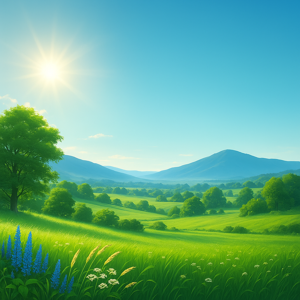

In [19]:
b24_data = response.data[0].b64_json

image_bytes = base64.b64decode(b24_data)
image = Image.open(BytesIO(image_bytes))
image.resize((300,300))